Downloads Rocket CEA to Colab

Declaring

In [8]:
import numpy as np
import math as math
import matplotlib.pyplot as plt
from rocketcea.cea_obj import CEA_Obj
from pyfluids import Fluid, Input, FluidsList

np.set_printoptions(legacy='1.25')

#psia to pascals conversion
psi_to_pa = 6894.76
#feet to meters conversion
ft_to_m = 0.3048
#m to cm
mcm = 100
#Rankine to Kelvin conversion
rankineToKelvin = 5.0 / 9.0
#Rankine to Fahrenheit conversion
rankineToFahrenheit = -459.67
#Kilogram to Pound conversion
kg_to_lb = 2.20462
#lbf to N conversion, N = kg-m/s^2
lbf_N = 4.4482216
#universal gas constant (J / mol-K)
Ru = 8.314
#m to in
m_in = 39.3701
#gravity in m/s^2
g = 9.81
#Efficieny factor of engine (estimate)
ef = 0.8

#Define CEA Object as C
C = CEA_Obj( oxName='GOX', fuelName='CH4')

#Variable Set Points
mdot =  0.01765    #kg/s MDOT @ 20% heat transfer efficiency
#mdot =  0.00353    #kg/s MDOT @ 100% heat transfer efficiency
pc = 300.0  #chosen chamber pressure (psia)
pc_pa = pc * psi_to_pa
of = 2.5  #chosen O/F ratio for our torch
Eps = 1.0  #chosen nozzle expansion ratio (1 for our torch)
Lstar = 20  #Characteristic length, in inches    #CHANGE THIS FOR CHAMBER SIZING


This piece of code is used for our plotting function to determine our O/F ratio

Diameter Throat Sizing Code

In [9]:
cf_arr = C.get_PambCf(Pamb = 14.7, Pc = pc, MR = of, eps = Eps)
cf = cf_arr[0] * ef #coefficient of thrust
cstar = C.get_Cstar(Pc = pc, MR = of) * ft_to_m * ef # C*  in m/s
tcomb = C.get_Tcomb(Pc = pc, MR = of) * rankineToKelvin
isp_s = C.get_Isp(Pc = pc, MR = of, eps = Eps)
isp = isp_s * g
mixing_efficiency = 0.8 # How shit injector is
v = 0.8 * isp # Multiply by 0.8 for efficiency factor

[mw, gamma_c] = C.get_Chamber_MolWt_gamma(Pc = pc, MR = of, eps = Eps)

At = (mdot / pc_pa) * np.sqrt((Ru * tcomb) / ((gamma_c)*((2)/(gamma_c + 1))**((gamma_c + 1)/(gamma_c - 1))))

mdot = (pc * psi_to_pa * At) / cstar #mass flow rate, assuming ambient pressure of free stream is equal to exit pressure (kg/s)
Dt_cm = 2 * np.sqrt(At / np.pi) * mcm #diameter of throat in centimeters
Dt_mm = 2 * np.sqrt(At / np.pi) * mcm * 10
Rt_mm = 2 * np.sqrt(At / np.pi) * mcm * 10 / 2

print(f'The temperature of combustion is {tcomb} degrees Fahrenheit')
print(f'The throat area is {At} square meters')
print(f'The throat diameter for our torch should be {Dt_mm : .4f} millimeters.')
print(f'The throat radius for our torch should be {Rt_mm : .4f} millimeters.')

The temperature of combustion is 3153.2923869235824 degrees Fahrenheit
The throat area is 2.158917100466349e-06 square meters
The throat diameter for our torch should be  1.6580 millimeters.
The throat radius for our torch should be  0.8290 millimeters.


This code is for sizing the orifices

In [ ]:
g_o = 1.40  #specific heat ratio for GOx (oxidizer is o)
g_f = 1.41  #specific heat ratio for GH2 (fuel is f)

crit_o = pc * ((g_o + 1) / 2) ** (g_o / (g_o - 1))
crit_f = pc * ((g_f + 1) / 2) ** (g_f / (g_f - 1))
print(f'The critical pressure for oxygen is {crit_o : 3f} psi')
print(f'The critical pressure for hyrdogen is {crit_f : 3f} psi')

The critical pressure for oxygen is  151.434333 psi
The critical pressure for hyrdogen is  151.917014 psi


In [ ]:
Cd = 0.80  #Coefficient of discharge, 0.8 - 0.9
stiffness = 0.4  #stiffness for both injectors at 20%

#Variables yet to be determined
#po_drop = stiffness * pc
#pf_drop = stiffness * pc

#P0_o = (2 * pc + po_drop) * psi_to_pa #upstream pressure of GOx
#P0_f = (2 * pc + pf_drop) * psi_to_pa  #upstream prssure of GH2

P0_o = crit_o * (1 + stiffness) * psi_to_pa
P0_f = crit_f * (1 + (2 * stiffness)) * psi_to_pa

print(f'upstream pressure of ox is {P0_o / psi_to_pa} psi')
print(f'upstream pressure of fuel is {P0_f / psi_to_pa} psi')

GOx_pyfluids = Fluid(FluidsList.Oxygen).with_state(Input.pressure(P0_o), Input.temperature(20))
GH2_pyfluids = Fluid(FluidsList.Hydrogen).with_state(Input.pressure(P0_f), Input.temperature(20))

rho_o = GOx_pyfluids.density  #density of GOx at (P0,T0), (kg/m^3)
rho_f = GH2_pyfluids.density  #density of GH2 at (P0,T0), (kg/m^3)

print(f'density of ox is {rho_o} kg/m^3')
print(f'density of h2 is {rho_f} kg/m^3')

crit_o = pc * (2 / (g_o + 1)) ** (g_o / (g_o - 1))
crit_f = pc * ((2 / (g_f + 1)) ** (g_f / (g_f - 1)))

mdot_f = mdot / (of + 1)  #fuel mass flow rate (kg/s)
mdot_o = (mdot - mdot_f) / 2  #oxidizer mass flow rate (kg/s)

print(f'The total mass flow rate is {(mdot * kg_to_lb): 3f} lb/s')
print(f'The total GOx mass flow rate is {mdot_o * 2 * kg_to_lb: 3f} lb/s')
print(f'Each GOx injector mass flow rate is {mdot_o * kg_to_lb: 3f} lb/s')
print(f'The GH2 mass flow rate is {mdot_f * kg_to_lb: 3f} lb/s')

#Cross sectional area of GOx orifice
A_o = mdot_o / (Cd * np.sqrt(g_o * rho_o * P0_o * ((2 / (g_o + 1)) ** ((g_o + 1) / (g_o - 1)))))
A_o_in = (A_o / (ft_to_m ** 2)) * 144
D_o_in = 2 * np.sqrt(A_o_in / np.pi)

#Cross sectional area of GH2 orifice
A_f = mdot_f / (Cd * np.sqrt(g_f * rho_f * P0_f * ((2 / (g_f + 1)) ** ((g_f + 1) / (g_f - 1)))))
A_f_in = (A_f / (ft_to_m ** 2)) * 144
D_f_in = 2 * np.sqrt(A_f_in / np.pi)

print(f'The cross sectional area for each GOx orifice should be {A_o_in : 2f} in^2')
print(f'The cross sectional area for the GH2 orifice should be {A_f_in : 2f} in^2')
print(f'The diameter for the GOx orifice should be {D_o_in : 2f} in')
print(f'The diameter for the GH2 orifice should be {D_f_in : 2f} in')

upstream pressure of ox is 181.72119923883398 psi
upstream pressure of fuel is 212.6838201194636 psi
density of ox is 16.590389687351486 kg/m^3
density of h2 is 1.2023342373364447 kg/m^3
The total mass flow rate is  0.019262 lb/s
The total GOx mass flow rate is  0.012841 lb/s
Each GOx injector mass flow rate is  0.006421 lb/s
The GH2 mass flow rate is  0.006421 lb/s
The cross sectional area for each GOx orifice should be  0.001807 in^2
The cross sectional area for the GH2 orifice should be  0.006191 in^2
The diameter for the GOx orifice should be  0.047972 in
The diameter for the GH2 orifice should be  0.088784 in


Code for chamber sizing

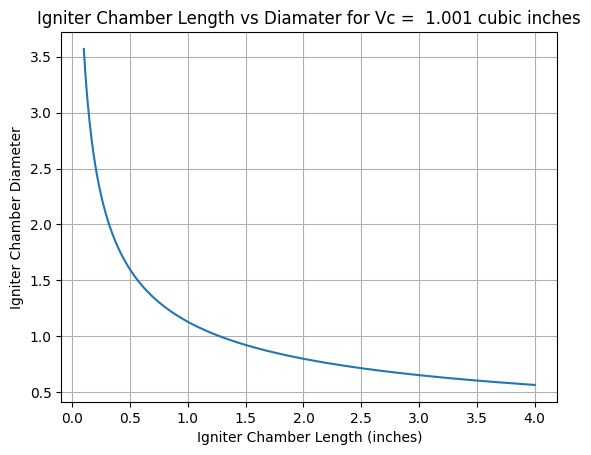

The chamber length will be  1.274 inches
The chamber diameter will be  1.000 inches


In [ ]:
L_star = 20  #Characteristic length of 20 inches

Vc_in = np.pi * (Dt_in / 2)**2 * L_star  #chamber volume in in^3 using Vc = At L*

L_range = np.linspace(0.1,4, 1000)
Dc_vals = [0] * len(L_range)

plt.figure(4)
count = 0
for Ls in L_range:
     Dc_vals[count] = 2 * np.sqrt((Vc_in / Ls)/ np.pi)
     count = count + 1
plt.plot(L_range, Dc_vals)
plt.xlabel("Igniter Chamber Length (inches)")
plt.ylabel("Igniter Chamber Diameter")
plt.title(f"Igniter Chamber Length vs Diamater for Vc = {Vc_in : .3f} cubic inches")
plt.grid()
plt.show()

Dc = 1

Lc = Vc_in / (np.pi * (Dc/2)**2)

ec = (Dc / Dt_in) ** 2

Lc_m = ((L_star * ft_to_m) - (((1.0/3.0) * np.sqrt(At / np.pi)) * (1 / np.tan(np.pi/4)) * (ec**(1.0/3.0) - 1))) / ec
Lc = Lc_m / ft_to_m

print(f'The chamber length will be {Lc : .3f} inches')
print(f'The chamber diameter will be {Dc : .3f} inches')


